In [1]:
from lfp_analysis_old import load_result
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import spectrogram
from scipy.signal import cwt, morlet
from lfp_analysis_new import *
from scipy.signal import butter, lfilter, filtfilt, spectrogram, sosfilt, stft
import pywt

In [13]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

In [2]:
def plot_spectrogram(t_original, lfp_original, t_downsampled, lfp_downsampled, dt, downsampled_dt):
    """
    Plots the spectrograms of the original and downsampled LFP signals.
    
    Parameters:
    t_original (array-like): Time points for the original LFP signal.
    lfp_original (array-like): Original LFP signal values.
    t_downsampled (array-like): Time points for the downsampled LFP signal.
    lfp_downsampled (array-like): Downsampled LFP signal values.
    dt (float): Time step (ms) for the original signal.
    downsampled_dt (float): Time step (ms) for the downsampled signal.
    """
    # Compute sampling frequencies
    fs_original = 1 / (dt / 1000)  # Convert ms to seconds
    fs_downsampled = 1 / (downsampled_dt / 1000)

    # Generate spectrograms
    f_original, t_spec_original, Sxx_original = spectrogram(lfp_original, fs=fs_original, nperseg=256, noverlap=128)
    f_downsampled, t_spec_downsampled, Sxx_downsampled = spectrogram(lfp_downsampled, fs=fs_downsampled, nperseg=256, noverlap=128)

    # Plot spectrograms
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Original signal spectrogram
    axes[0].pcolormesh(t_spec_original, f_original, 10 * np.log10(Sxx_original), shading='jet')
    axes[0].set_title('Spectrogram of Original LFP Signal')
    axes[0].set_ylabel('Frequency (Hz)')
    axes[0].set_ylim(0, 200)  # Limit to 200 Hz

    # Downsampled signal spectrogram
    axes[1].pcolormesh(t_spec_downsampled, f_downsampled, 10 * np.log10(Sxx_downsampled), shading='jet')
    axes[1].set_title('Spectrogram of Downsampled LFP Signal')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_ylim(0, 200)  # Limit to 200 Hz

    plt.tight_layout()
    plt.show()

In [8]:
# Define bandpass filter function with adjustable filter type and dt in milliseconds
def bandpass_filter(data, lowcut, highcut, dt, order=5, filter_type='filtfilt'):
    """
    Bandpass filters the data between lowcut and highcut frequencies.
    
    Parameters:
    - data: array-like, the signal to be filtered
    - lowcut: float, lower cutoff frequency in Hz
    - highcut: float, higher cutoff frequency in Hz
    - dt: float, time step in milliseconds
    - order: int, order of the filter
    - filter_type: str, 'filtfilt' (zero-phase filtering) or 'lfilter' (causal filtering)
    
    Returns:
    - y: array-like, the bandpass-filtered signal
    """
    fs = 1000.0 / dt  # Convert dt in ms to sampling frequency in Hz
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    
    if filter_type == 'filtfilt':
        y = filtfilt(b, a, data)
    elif filter_type == 'lfilter':
        y = lfilter(b, a, data)
    else:
        raise ValueError("filter_type must be 'filtfilt' or 'lfilter'")
    
    return y

# Define function to plot bandpassed signals
def plot_bandpassed_signals(lfp_signal, t, dt, filter_type='filtfilt', order=5):
    """
    Plots the original LFP signal and its bandpass-filtered versions in different frequency bands.
    
    Parameters:
    - lfp_signal: array-like, original LFP signal
    - t: array-like, time vector corresponding to the signal
    - dt: float, time step in milliseconds
    - filter_type: str, filter type ('filtfilt' or 'lfilter') used for bandpass filtering
    - order: int, order of the bandpass filter
    """
    # Bandpass filter for different frequency ranges
    low_freq_signal = bandpass_filter(lfp_signal, 3, 40, dt, order=order, filter_type=filter_type)
    medium_freq_signal = bandpass_filter(lfp_signal, 40, 100, dt, order=order, filter_type=filter_type)
    high_freq_signal = bandpass_filter(lfp_signal, 100, 200, dt, order=order, filter_type=filter_type)

    # Create subplots
    fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

    # Plot the original LFP signal
    ax[0].plot(t, lfp_signal, color='black', label='Original LFP Signal')
    ax[0].set_title('Original LFP Signal')
    ax[0].set_ylabel('Amplitude')
    #ax[0].set_ylim(-1.1, 1.1)
    ax[0].legend(loc='upper right')

    # Plot the low-frequency bandpassed signal
    ax[1].plot(t, low_freq_signal, color='blue', label='3-40 Hz Bandpass')
    ax[1].set_title(f'Low Frequency (3 - 40 Hz) Bandpass | Filter: {filter_type}, Order: {order}')
    ax[1].set_ylabel('Amplitude')
    #ax[1].set_ylim(-1.1, 1.1)
    ax[1].legend(loc='upper right')

    # Plot the medium-frequency bandpassed signal
    ax[2].plot(t, medium_freq_signal, color='green', label='100-200 Hz Bandpass')
    ax[2].set_title(f'Medium Frequency (100 - 200 Hz) Bandpass | Filter: {filter_type}, Order: {order}')
    ax[2].set_ylabel('Amplitude')
    #ax[2].set_ylim(-1.1, 1.1)
    ax[2].legend(loc='upper right')

    # Plot the high-frequency bandpassed signal
    ax[3].plot(t, high_freq_signal, color='red', label='100-200 Hz Bandpass')
    ax[3].set_title(f'High Frequency (100-200 Hz) Bandpass | Filter: {filter_type}, Order: {order}')
    ax[3].set_xlabel('Time (s)')
    ax[3].set_ylabel('Amplitude')
    #ax[3].set_ylim(-1.1, 1.1)
    ax[3].legend(loc='upper right')

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()



In [33]:
def plot_wavelet_spectrogram(t, lfp, dt, num_scales=50, wavelet="cgau5"):
    # The wavelet transform piece of load_result, and the parameters Justas set:
    # Band pass filter LFP
    lfp_bp = butter_bandpass_filter(lfp, 1,200, 1/dt*1000, order=4)
    # Wavelet decomposition

    scale_low=3 
    scale_high=200
    scales = np.linspace(scale_low/dt, scale_high/dt, num_scales)
    cfs, frequencies = pywt.cwt(lfp_bp, scales, wavelet, dt / 1000.0)
    lfp_wavelet_power = np.log(1+abs(cfs))

    plt.subplots(figsize=(18, 5))
    plt.contourf(t, frequencies, lfp_wavelet_power, 256,cmap='Blues')
    plt.ylim((1,200))
    plt.xticks(np.arange(round(min(t)), max(t)+1, 50.0))
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Simulation Time [ms]')
    plt.title(f"Wavelet type {wavelet}, # of scales = {num_scales}")
    plt.show()

In [4]:
# Example usage
dt = 0.1  # ms time step
duration = 2000  # ms (2 seconds)
t = np.arange(0, duration, dt) / 1000  # Time vector in seconds

# Create an LFP signal with low (5 Hz), medium (40 Hz), and high-frequency (150 Hz) components, plus noise
lfp_signal = (0.2 * np.sin(2 * np.pi * 5 * t) +              # 5 Hz component
             0.3 * np.sin(2 * np.pi * 40 * t) +             # 40 Hz component
             (0.5 * np.sin(2 * np.pi * 0.5 * t)) *          # Envelope at 0.5 Hz
             np.sin(2 * np.pi * 150 * t) +                  # 150 Hz component w varying amplitude
             0.1 * np.random.randn(len(t)))                 # Random noise




In [5]:
events, vs, spike_times, t, lfp, lfp_bp_beta, lfp_bp_gamma, lfp_bp_hfo, \
        lfp_wavelet_power, scales, wavelet, dt, frequencies, t_average, lfp_wavelet_power_average, params_dict = load_result("GammaSignature_SetupTime")



/home/ellismith/OlfactoryBulb-1/results


In [6]:

n=10
dt_downsampled = dt*n
t_ds, lfp_ds = downsample_lfp(t, lfp, n)

print(f"Original length: {len(t)}, Downsampled length: {len(t_ds)}")

Original length: 17999, Downsampled length: 1800


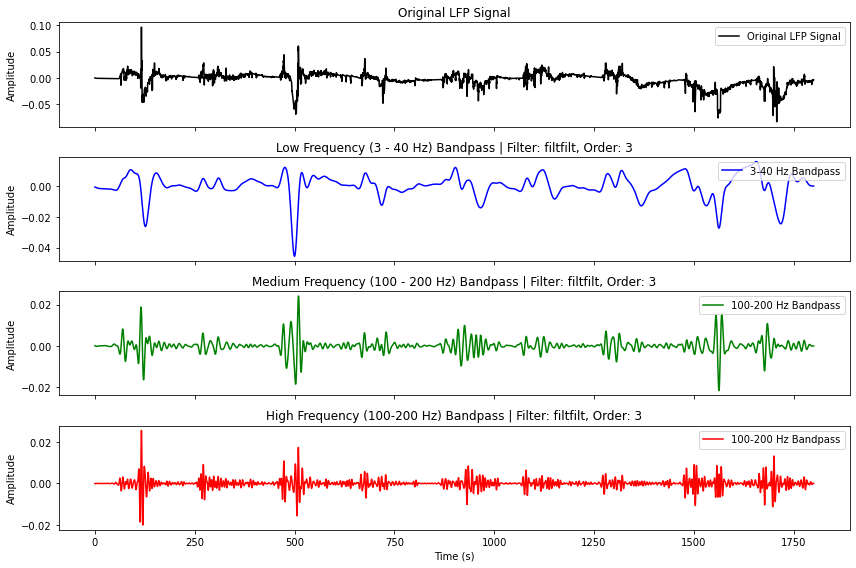

In [10]:
plot_bandpassed_signals(lfp, t, dt, filter_type='filtfilt', order=3)

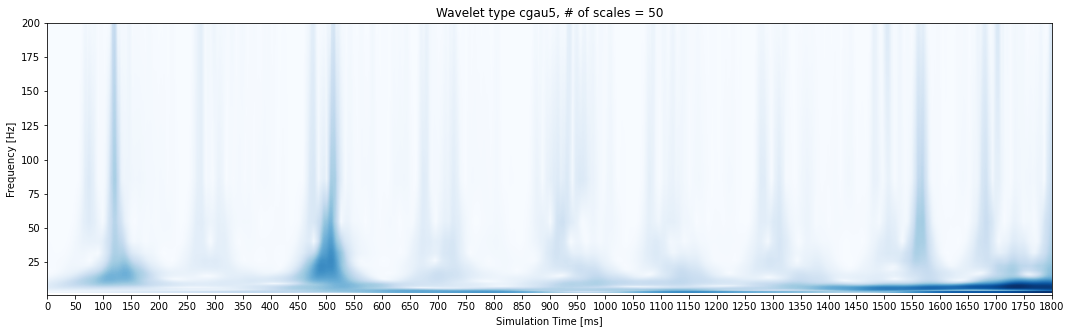

In [34]:
plot_wavelet_spectrogram(t, lfp, dt, num_scales=50, wavelet="cgau5")

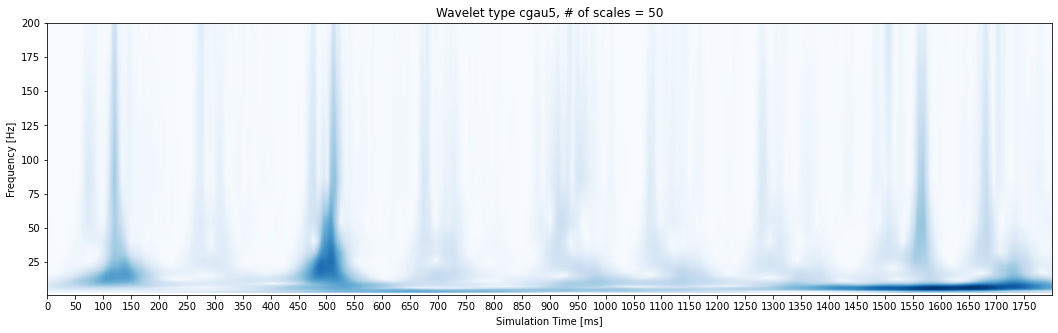

In [35]:
plot_wavelet_spectrogram(t_ds, lfp_ds, dt_downsampled, num_scales=50, wavelet="cgau5")

In [36]:
len(t_ds)

1800

In [ ]:
plot_bandpassed_signals(lfp_signal, t, dt, filter_type='filtfilt', order=5)

/home/ellismith/.conda/envs/OBModel_linux/lib/python3.7/site-packages/ipykernel_launcher.py:25: UserWarning: shading value 'jet' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
/home/ellismith/.conda/envs/OBModel_linux/lib/python3.7/site-packages/ipykernel_launcher.py:31: UserWarning: shading value 'jet' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.


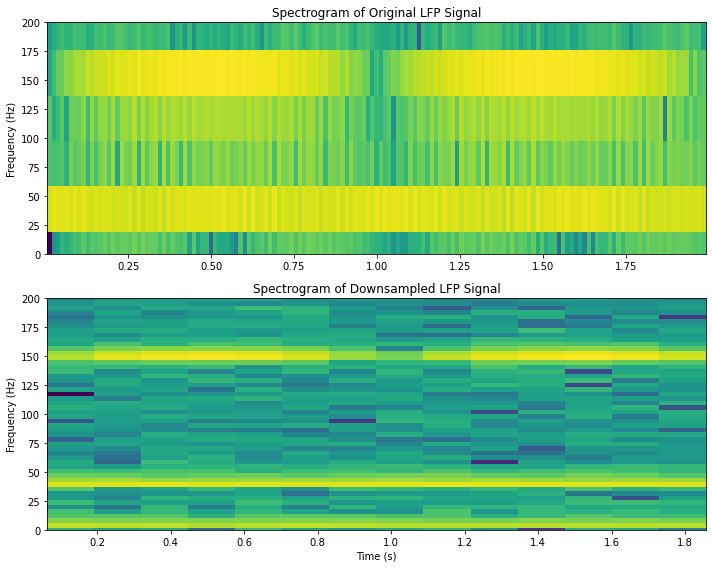

In [9]:
plot_spectrogram(t, lfp_signal, t_downsampled, lfp_downsampled, dt, dt_downsampled)

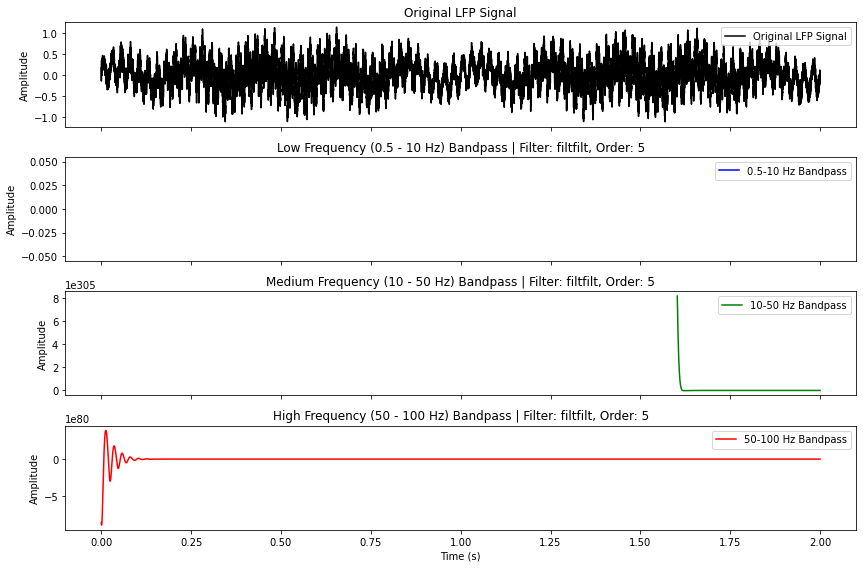

In [11]:

# Plot the signal and its bandpass-filtered versions using 'filtfilt' and order 5
plot_bandpassed_signals(lfp_signal, t, dt, filter_type='filtfilt', order=5)

/home/ellismith/.conda/envs/OBModel_linux/lib/python3.7/site-packages/ipykernel_launcher.py:25: UserWarning: shading value 'jet' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
/home/ellismith/.conda/envs/OBModel_linux/lib/python3.7/site-packages/ipykernel_launcher.py:31: UserWarning: shading value 'jet' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.


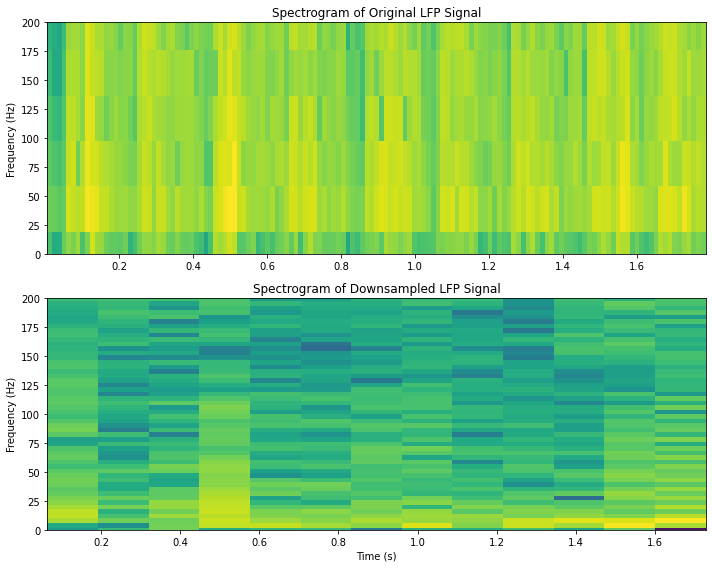

In [40]:
plot_spectrogram(t, lfp, t_ds, lfp_ds, dt=0.1, downsampled_dt=0.1 * n)

In [ ]:
def plot_wavelet_spectrogram_ds(t_original, lfp_original, t_downsampled, lfp_downsampled, dt, downsampled_dt, min_freq=1, max_freq=200):
    """
    Plots wavelet-based time-frequency representation (CWT) of the original and downsampled LFP signals.
    
    Parameters:
    t_original (array-like): Time points for the original LFP signal.
    lfp_original (array-like): Original LFP signal values.
    t_downsampled (array-like): Time points for the downsampled LFP signal.
    lfp_downsampled (array-like): Downsampled LFP signal values.
    dt (float): Time step (ms) for the original signal.
    downsampled_dt (float): Time step (ms) for the downsampled signal.
    min_freq (float): Minimum frequency to display (Hz).
    max_freq (float): Maximum frequency to display (Hz).
    """
    # Compute sampling frequencies
    fs_original = 1 / (dt / 1000)  # Convert ms to seconds
    fs_downsampled = 1 / (downsampled_dt / 1000)

    # Generate wavelet transform (CWT) for both signals
    frequencies = np.arange(min_freq, max_freq, 1)  # Frequency range from min_freq to max_freq
    cwt_original = cwt(lfp_original, morlet, frequencies)
    cwt_downsampled = cwt(lfp_downsampled, morlet, frequencies)
    
    # Plot CWT spectrograms
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Original signal CWT
    im1 = axes[0].imshow(np.abs(cwt_original), aspect='auto', extent=[t_original[0], t_original[-1], max_freq, min_freq], cmap='jet')
    axes[0].set_title('Wavelet Spectrogram of Original LFP Signal')
    axes[0].set_ylabel('Frequency (Hz)')
    axes[0].set_xlabel('Time (ms)')
    fig.colorbar(im1, ax=axes[0])

    # Downsampled signal CWT
    im2 = axes[1].imshow(np.abs(cwt_downsampled), aspect='auto', extent=[t_downsampled[0], t_downsampled[-1], max_freq, min_freq], cmap='jet')
    axes[1].set_title('Wavelet Spectrogram of Downsampled LFP Signal')
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_xlabel('Time (ms)')
    fig.colorbar(im2, ax=axes[1])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_wavelet_spectrogram(t, lfp_signal, dt, num_scales=100, wavelet="cmor1.5-1.5")

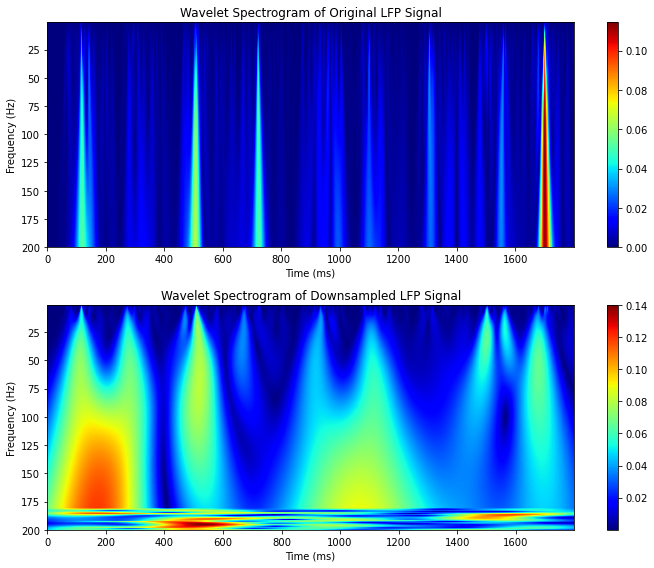

In [43]:
# Plot spectrograms using wavelet transform
plot_wavelet_spectrogram(t, lfp, t_ds, lfp_ds, dt=0.1, downsampled_dt=0.1 * n)